In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 0.74  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -1.11675931 Ha
FCI能量: -1.13728383 Ha


SpinOrbitalFermions 是 NetKet（特别是 netket ≥ v3.10 之后，或通过 netket.experimental）中用于描述具有自旋的费米子系统的希尔伯特空间（Hilbert space）类。它专为处理电子结构问题（如分子、固体中的多电子系统）而设计，天然支持泡利不相容原理和固定粒子数约束。

SpinOrbitalFermions 定义了一个由自旋轨道占据数构成的离散希尔伯特空间，每个自旋轨道只能被占据（1）或空（0），且满足：

费米子统计（自动通过占据数表示处理）
可选：固定总电子数、固定自旋向上/向下电子数


In [2]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
cluster = [(0,1),(2,3)]
#

# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=[(0,1),(2,3)])
# g = nk.graph.Graph(edges=cluster)
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [5]:
import jax
import jax.numpy as jnp
from flax import nnx

class AntisymmetricFFN(nnx.Module):
    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)
    
    def __call__(self, x: jax.Array):
        # 计算原始波函数
        y = self.linear(x)
        y = nnx.relu(y)
        psi_raw = jnp.sum(y, axis=-1)
        
        # 手动实现反对称性
        # 对于2电子系统：ψ(r₁,r₂) = -ψ(r₂,r₁)
        
        # 使用 jnp.nonzero 并指定 size 参数
        occupied = jnp.nonzero(x == 1, size=x.shape[0], fill_value=-1)[0]
        
        # 使用 jnp.where 过滤填充值
        valid_mask = occupied >= 0
        occupied = jnp.where(valid_mask, occupied, jnp.full_like(occupied, -1))
        
        # 计算有效电子数
        n_electrons = jnp.sum(valid_mask)
        
        # 使用条件操作而不是 if 语句
        def antisymmetric_case():
            # 交换两个电子的位置
            x_swapped = x.copy()
            x_swapped = x_swapped.at[occupied[0]].set(x[occupied[1]])
            x_swapped = x_swapped.at[occupied[1]].set(x[occupied[0]])
            
            # 计算交换后的波函数
            y_swapped = self.linear(x_swapped)
            y_swapped = nnx.relu(y_swapped)
            psi_swapped = jnp.sum(y_swapped, axis=-1)
            
            # 反对称化
            return psi_raw - psi_swapped
        
        def symmetric_case():
            return psi_raw
        
        # 使用 jnp.cond 替代 if 语句
        return jax.lax.cond(n_electrons == 2, antisymmetric_case, symmetric_case)


In [6]:
N = 4
ffnn_model = AntisymmetricFFN(N=N, alpha=1, rngs=nnx.Rngs(2))
vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
exp_name = "h2_molecule_ffnn"

In [7]:
gs.run(300, out=exp_name)

100%|██████████| 300/300 [00:05<00:00, 52.24it/s, Energy=-1.1148 ± 0.0017 [σ²=0.0016, R̂=1.0146]]         


(JsonLog('h2_molecule_ffnn', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.027326107025146484
   	Params: 0.026702404022216797,)

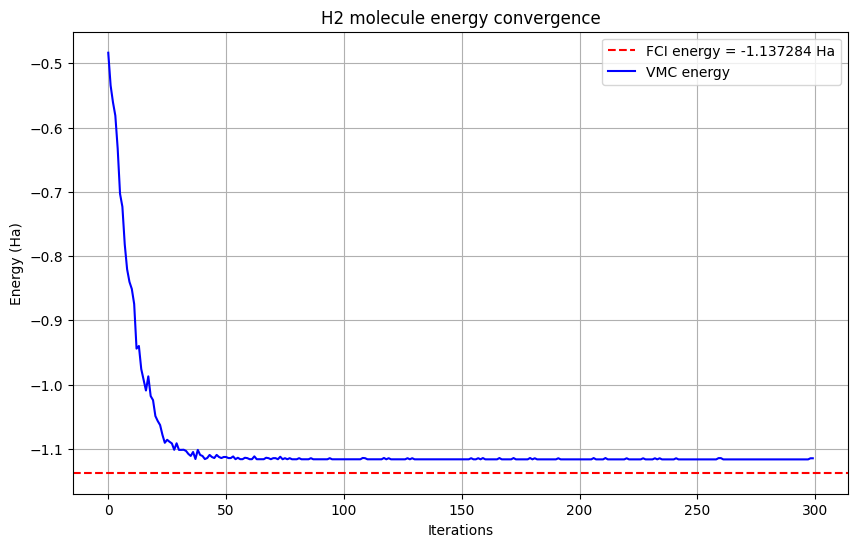


最终VMC能量: -1.11479723 Ha
与FCI能量误差: 0.02248661 Ha


In [8]:
############## 绘图 #################

# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.plot(x, y, 'b-', label="VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("H2 molecule energy convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")


In [9]:
# 检查NetKet是否自动处理对称性
print("采样器类型:", type(sa))
print("希尔伯特空间:", hi)

# 测试两个交换的电子构型
config1 = jnp.array([1, 0, 1, 0])  # 电子1在轨道0，电子2在轨道2
config2 = jnp.array([0, 1, 0, 1])  # 交换后的构型



采样器类型: <class 'netket.sampler.metropolis.MetropolisSampler'>
希尔伯特空间: SpinOrbitalFermions(n_orbitals=2, s=1/2, n_fermions=2, n_fermions_per_spin=(1, 1))


In [10]:
psi1 = ffnn_model(config1)
psi2 = ffnn_model(config2)

print(f"ψ(config1) = {psi1}")
print(f"ψ(config2) = {psi2}")
print(f"比率 ψ2/ψ1 = {psi2/psi1}")

ψ(config1) = 0.0
ψ(config2) = 0.0
比率 ψ2/ψ1 = nan


In [11]:
model = ffnn_model

In [12]:
import jax.numpy as jnp

# 定义交换操作函数
def swap_electrons(config, i, j):
    """交换电子i和j的位置"""
    new_config = config.copy()
    new_config = new_config.at[i].set(config[j])
    new_config = new_config.at[j].set(config[i])
    return new_config

# 测试多个交换情况
test_configs = [
    jnp.array([1, 0, 1, 0]),  # 基态
    jnp.array([1, 1, 0, 0]),  # 激发态
    jnp.array([0, 1, 1, 0]),  # 另一个构型
]

print("费米子对称性测试:")
print("=" * 50)

for i, config in enumerate(test_configs):
    print(f"\n构型 {i+1}: {config}")
    
    # 测试所有可能的电子交换
    electrons = jnp.where(config == 1)[0]
    
    for j in range(len(electrons)):
        for k in range(j+1, len(electrons)):
            e1, e2 = electrons[j], electrons[k]
            
            # 交换电子
            swapped_config = swap_electrons(config, e1, e2)
            
            # 计算波函数值
            psi_original = model(config.reshape(1, -1))[0]
            psi_swapped = model(swapped_config.reshape(1, -1))[0]
            
            ratio = psi_swapped / psi_original if psi_original != 0 else jnp.inf
            
            print(f"  交换轨道{e1}和{e2}: ψ' = {psi_swapped:.6f}, 比率 = {ratio:.6f}")
            
            # 检查是否接近-1
            if abs(ratio + 1.0) > 0.1:  # 容差0.1
                print(f"    ❌ 不满足反对称性！")
            else:
                print(f"    ✅ 满足反对称性")


费米子对称性测试:

构型 1: [1 0 1 0]
  交换轨道0和2: ψ' = 2.494493, 比率 = 1.000000
    ❌ 不满足反对称性！

构型 2: [1 1 0 0]
  交换轨道0和1: ψ' = 0.711886, 比率 = 1.000000
    ❌ 不满足反对称性！

构型 3: [0 1 1 0]
  交换轨道1和2: ψ' = 2.788367, 比率 = 1.000000
    ❌ 不满足反对称性！
